Deep learning model with sample prediction and confusion matrix for evaluating and selecting pharma clinical research scientist role using features, Features might include: - Attention to Detail - Analytical Thinking - Ethical Reasoning - Stress Tolerance - Communication Skills - Teamwork Orientation - Research Experience (years) - Problem Solving Ability - Conscientiousness - Openness to Experience

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
n_samples = 1000

# Features: 0-10 scale for behavioral, years for experience
data = {
    'Attention_to_Detail': np.random.randint(5, 11, n_samples),
    'Analytical_Thinking': np.random.randint(4, 11, n_samples),
    'Ethical_Reasoning': np.random.randint(6, 11, n_samples),
    'Stress_Tolerance': np.random.randint(3, 11, n_samples),
    'Communication_Skills': np.random.randint(5, 11, n_samples),
    'Teamwork_Orientation': np.random.randint(4, 11, n_samples),
    'Research_Experience': np.random.randint(0, 15, n_samples),
    'Problem_Solving': np.random.randint(4, 11, n_samples),
    'Conscientiousness': np.random.randint(5, 11, n_samples),
    'Openness': np.random.randint(4, 11, n_samples)
}

df = pd.DataFrame(data)

# Create Target: Suitable(1) if high analytical/exp, else 0
# Logic: Sum of key skills > threshold
score = (df['Analytical_Thinking'] * 1.5 + df['Research_Experience'] * 0.8 + df['Attention_to_Detail'] * 1.2)
df['Suitable'] = (score > 25).astype(int)

X = df.drop('Suitable', axis=1)
y = df['Suitable']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1. Data Preparation (Example Dataset Generation)
# Replace this with loading your actual csv data
data = {
    'adverse_events': np.random.randint(10, 100, 1000),
    'response_time': np.random.uniform(1, 48, 1000),
    'deviation_catches': np.random.randint(0, 20, 1000),
    'data_issues': np.random.randint(0, 10, 1000),
    'experience': np.random.randint(1, 15, 1000),
    'studies_monitored': np.random.randint(1, 30, 1000),
    'compliance_rate': np.random.uniform(0.7, 1.0, 1000),
    'comm_score': np.random.uniform(1, 5, 1000),
    'doc_quality': np.random.uniform(1, 5, 1000),
    'label': np.random.randint(0, 2, 1000)  # 1: Selected, 0: Not Selected
}
df = pd.DataFrame(data)

# Features and Target
X = df.drop('label', axis=1)
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Build the Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 5. Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 6. Predict for a new Medical Monitor
new_monitor = np.array([[50, 5, 15, 2, 10, 20, 0.98, 4.5, 4.8]])
new_monitor_scaled = scaler.transform(new_monitor)
prediction = model.predict(new_monitor_scaled)
print(f"Selection Probability: {prediction[0][0]:.2f}")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5271 - loss: 0.9408 - val_accuracy: 0.3625 - val_loss: 0.7982
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5294 - loss: 0.8050 - val_accuracy: 0.3500 - val_loss: 0.7396
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5298 - loss: 0.7981 - val_accuracy: 0.4375 - val_loss: 0.7162
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5375 - loss: 0.7596 - val_accuracy: 0.5000 - val_loss: 0.7103
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5150 - loss: 0.7738 - val_accuracy: 0.4875 - val_loss: 0.7153
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5526 - loss: 0.7372 - val_accuracy: 0.4750 - val_loss: 0.7098
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5604 - loss: 0.7085 - val_accuracy: 0.4500 - val_loss: 0.7120
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5705 - loss: 0.6955 - val_accuracy: 0.4625 - val_loss: 0.7141
Ep

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary Output
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train Model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_split=0.1, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


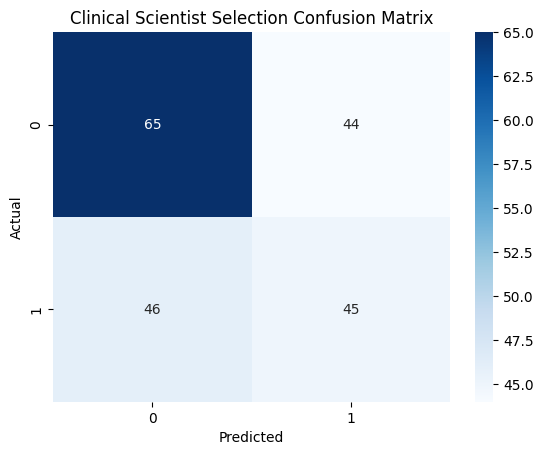

              precision    recall  f1-score   support

           0       0.59      0.60      0.59       109
           1       0.51      0.49      0.50        91

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.55      0.55      0.55       200



In [ ]:
# Predict
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Clinical Scientist Selection Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))
